# Signal Quality & Preprocessing Characterization

**Purpose:** Characterize inter-site heterogeneity in raw signal properties and
preprocessing outcomes (frame rejection rates, signal amplitudes) for the
30 institutions in ELM_n (normal recordings only).

**Outputs:**

| File | Description |
|------|-------------|
| `results/figures/01_exploratory_analysis/raw_amplitude_by_hospital.png` | Raw signal amplitude (median MAD) per site |
| `results/figures/01_exploratory_analysis/rejection_rate_by_hospital.png` | Frame rejection rate per site |
| `results/tables/01_exploratory_analysis/signal_quality_stats.csv` | Per-site signal quality summary |

## Setup

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

PROJECT_ROOT = Path(os.environ.get('PROJECT_ROOT', Path.cwd().parents[1]))
DATA_DIR     = PROJECT_ROOT / 'data' / 'ELM19'
FIG_DIR      = PROJECT_ROOT / 'results' / 'figures' / '01_exploratory_analysis'
TAB_DIR      = PROJECT_ROOT / 'results' / 'tables'  / '01_exploratory_analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

DPI = 200
FIGSIZE_WIDE = (14, 5)

# Anonymization mapping
anon_df = pd.read_csv(DATA_DIR / 'hospital_anonymization_mapping.csv')
ANON_MAP = dict(zip(anon_df['Original_Hospital'], anon_df['Anonymized_ID']))
ANON_ORDER = [f'H{i}' for i in range(1, 31)]

print(f'Project root: {PROJECT_ROOT}')
print(f'Figures → {FIG_DIR}')
print(f'Tables  → {TAB_DIR}')

Project root: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects
Figures → /dmj/fizmed/kchorzela/licencjat/eeg-site-effects/results/figures/01_exploratory_analysis
Tables  → /dmj/fizmed/kchorzela/licencjat/eeg-site-effects/results/tables/01_exploratory_analysis


## Load preprocessing metrics

In [2]:
# Load per-recording preprocessing metrics
metrics = pd.read_csv(DATA_DIR / 'experiments' / 'original' / 'metrics.csv')
print(f'Total recordings in metrics: {len(metrics):,}')

# Filter to ELM_s institutions and anonymize
metrics = metrics[metrics['institution_id'].isin(ANON_MAP.keys())].copy()
metrics['site'] = metrics['institution_id'].map(ANON_MAP)
print(f'Recordings in ELM_s: {len(metrics):,}')

# Filter to successfully preprocessed recordings
metrics_ok = metrics[metrics['preprocessing_successful'] == True].copy()
print(f'Successfully preprocessed: {len(metrics_ok):,}')
print(f'Failed: {(~metrics["preprocessing_successful"]).sum()}')

# Filter to ELM_n (normal recordings only)
info = pd.read_csv(DATA_DIR / 'ELM19_enriched_info.csv')
norm_ids = set(info[info['classification'] == 'norm']['examination_id'])
metrics_ok = metrics_ok[metrics_ok['examination_id'].isin(norm_ids)].copy()
print(f'ELM_n (normal only): {len(metrics_ok):,}')

Total recordings in metrics: 54,779
Recordings in ELM_s: 54,779
Successfully preprocessed: 54,779
Failed: 0


ELM_n (normal only): 26,568


## Raw signal amplitude by site

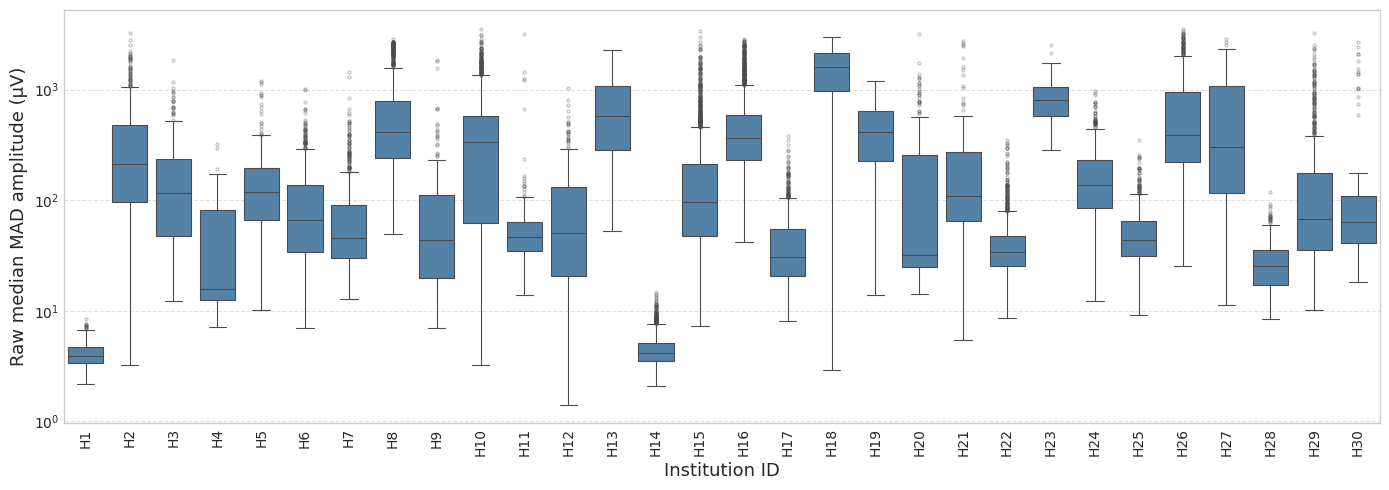

Saved raw_amplitude_by_hospital.png


In [3]:
# Raw signal amplitude (median MAD across channels) – boxplot
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.boxplot(
    data=metrics_ok,
    x='site', y='raw_median_mad_uv',
    order=ANON_ORDER,
    color='steelblue',
    linewidth=0.8,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax,
)
ax.set_xlabel('Institution ID', fontsize=13)
ax.set_ylabel('Raw median MAD amplitude (µV)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.set_yscale('log')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_amplitude_by_hospital.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved raw_amplitude_by_hospital.png')

In [4]:
# Per-site amplitude summary
amp_stats = (
    metrics_ok.groupby('site')['raw_median_mad_uv']
    .agg(mean='mean', median='median', std='std', min='min', max='max')
    .round(2)
    .reindex(ANON_ORDER)
)
print('Per-site raw signal amplitude (median MAD, µV):')
print(f'  Lowest median:  {amp_stats["median"].idxmin()} = {amp_stats["median"].min():.1f} µV')
print(f'  Highest median: {amp_stats["median"].idxmax()} = {amp_stats["median"].max():.1f} µV')
print(f'  Ratio: {amp_stats["median"].max() / amp_stats["median"].min():.0f}x')
print()
amp_stats

Per-site raw signal amplitude (median MAD, µV):
  Lowest median:  H1 = 3.9 µV
  Highest median: H18 = 1610.6 µV
  Ratio: 412x



,mean,median,std,min,max
site,,,,,
H1,4.16,3.91,1.06,2.17,8.41
H2,373.05,212.25,433.54,3.24,3282.72
H3,178.08,115.38,195.85,12.34,1833.63
H4,46.64,15.74,53.86,7.16,319.78
H5,164.16,117.71,171.38,10.20,1186.94
H6,101.84,66.19,104.01,6.98,1012.79
H7,84.94,45.56,116.75,12.88,1434.16
H8,694.72,412.37,698.18,49.46,2845.13
H9,96.98,43.91,186.37,7.06,1839.60


## Frame rejection rates by site

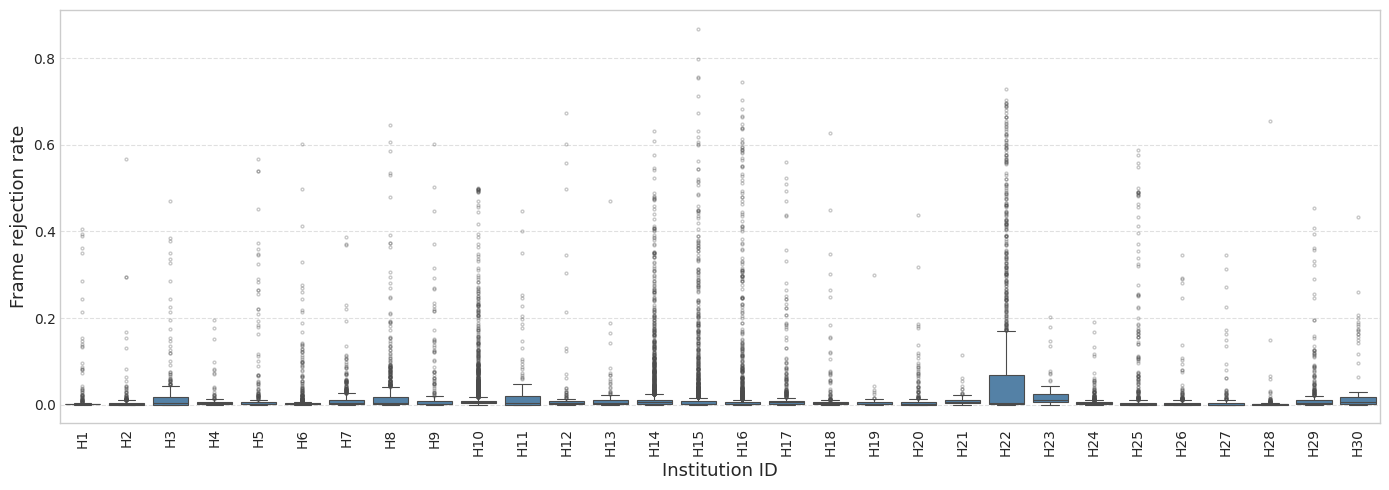

Saved rejection_rate_by_hospital.png


In [5]:
# Rejection rate – boxplot
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.boxplot(
    data=metrics_ok,
    x='site', y='rejection_rate',
    order=ANON_ORDER,
    color='steelblue',
    linewidth=0.8,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax,
)
ax.set_xlabel('Institution ID', fontsize=13)
ax.set_ylabel('Frame rejection rate', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(FIG_DIR / 'rejection_rate_by_hospital.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved rejection_rate_by_hospital.png')

In [6]:
# Per-site rejection rate summary
rej_stats = (
    metrics_ok.groupby('site')['rejection_rate']
    .agg(mean='mean', median='median', std='std')
    .round(4)
    .reindex(ANON_ORDER)
)
print('Per-site frame rejection rates:')
print(f'  Overall mean: {metrics_ok["rejection_rate"].mean():.3f}')
print(f'  Overall median: {metrics_ok["rejection_rate"].median():.3f}')
print(f'  Site with highest mean: {rej_stats["mean"].idxmax()} = {rej_stats["mean"].max():.3f}')
print(f'  Site with lowest mean:  {rej_stats["mean"].idxmin()} = {rej_stats["mean"].min():.3f}')
print()
rej_stats

Per-site frame rejection rates:
  Overall mean: 0.020
  Overall median: 0.004
  Site with highest mean: H22 = 0.082
  Site with lowest mean:  H28 = 0.004



,mean,median,std
site,,,
H1,0.0153,0.0013,0.0561
H2,0.0062,0.0019,0.0290
H3,0.0202,0.0044,0.0514
H4,0.0097,0.0050,0.0225
H5,0.0281,0.0020,0.0839
H6,0.0094,0.0020,0.0371
H7,0.0129,0.0046,0.0315
H8,0.0221,0.0047,0.0586
H9,0.0245,0.0021,0.0702


## Rejection breakdown: amplitude vs flat-line

In [7]:
# Breakdown of rejection reasons
rej_breakdown = (
    metrics_ok.groupby('site')[['total_segments', 'rejected_amplitude', 'rejected_flat', 'segments_kept']]
    .sum()
    .reindex(ANON_ORDER)
)
rej_breakdown['pct_rejected_amplitude'] = (rej_breakdown['rejected_amplitude'] / rej_breakdown['total_segments'] * 100).round(2)
rej_breakdown['pct_rejected_flat'] = (rej_breakdown['rejected_flat'] / rej_breakdown['total_segments'] * 100).round(2)
rej_breakdown['pct_total_rejected'] = ((rej_breakdown['rejected_amplitude'] + rej_breakdown['rejected_flat']) / rej_breakdown['total_segments'] * 100).round(2)

print('Rejection breakdown (% of total segments):')
print(rej_breakdown[['pct_rejected_amplitude', 'pct_rejected_flat', 'pct_total_rejected']].to_string())

Rejection breakdown (% of total segments):
      pct_rejected_amplitude  pct_rejected_flat  pct_total_rejected
site                                                               
H1                      0.09               1.40                1.48
H2                      0.24               0.37                0.61
H3                      0.70               1.43                2.13
H4                      0.20               0.76                0.96
H5                      0.38               2.53                2.90
H6                      0.08               0.87                0.95
H7                      0.74               0.49                1.23
H8                      1.01               1.03                2.04
H9                      0.16               2.29                2.45
H10                     0.53               0.87                1.40
H11                     0.41               2.49                2.90
H12                     0.34               1.87                2.20
H13  

## Combined summary table

In [8]:
# Build combined signal quality table
summary = pd.DataFrame(index=ANON_ORDER)
summary.index.name = 'institution_id'

summary['n_recordings'] = metrics_ok.groupby('site').size().reindex(ANON_ORDER)
summary['raw_amp_median_uv'] = amp_stats['median']
summary['raw_amp_mean_uv'] = amp_stats['mean']
summary['rejection_rate_mean'] = rej_stats['mean']
summary['rejection_rate_median'] = rej_stats['median']
summary['pct_rejected_amplitude'] = rej_breakdown['pct_rejected_amplitude']
summary['pct_rejected_flat'] = rej_breakdown['pct_rejected_flat']

summary.to_csv(TAB_DIR / 'signal_quality_stats.csv')
print('Saved signal_quality_stats.csv')
summary

Saved signal_quality_stats.csv


,n_recordings,raw_amp_median_uv,raw_amp_mean_uv,rejection_rate_mean,rejection_rate_median,pct_rejected_amplitude,pct_rejected_flat
institution_id,,,,,,,
H1,318,3.91,4.16,0.0153,0.0013,0.09,1.40
H2,691,212.25,373.05,0.0062,0.0019,0.24,0.37
H3,473,115.38,178.08,0.0202,0.0044,0.70,1.43
H4,237,15.74,46.64,0.0097,0.0050,0.20,0.76
H5,315,117.71,164.16,0.0281,0.0020,0.38,2.53
H6,1148,66.19,101.84,0.0094,0.0020,0.08,0.87
H7,752,45.56,84.94,0.0129,0.0046,0.74,0.49
H8,1033,412.37,694.72,0.0221,0.0047,1.01,1.03
H9,336,43.91,96.98,0.0245,0.0021,0.16,2.29
